# Supplementary Model Analysis

This notebook is dedicated to three follow-up analyses for the 3/4 report:

1. Feature-group ablation study
2. Model performance by user segment
3. Top-K strategy comparison

It reuses the prepared dataset and the fixed best parameters from the main modeling notebook.


In [1]:
from __future__ import annotations

import ast
import json
from collections import Counter
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from catboost import CatBoostClassifier
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, f1_score, log_loss, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import GroupKFold
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', 200)


In [2]:
PROJECT_ROOT = Path('/Users/bettinabopeng/Documents/GitHub/5971')
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'
DATASET_PATH = ARTIFACTS_DIR / 'model_dataset_full.parquet'
METADATA_PATH = ARTIFACTS_DIR / 'model_dataset_full.metadata.json'
CATBOOST_TUNING_PATH = ARTIFACTS_DIR / 'catboost_tuning_no_als.csv'

RANDOM_STATE = 42
OUTER_SPLITS = 3
TOP_K_FIXED = 11

# Heavy analyses can be slow, especially with CatBoost.
ANALYSIS_MODELS = ['LogisticRegression_SAGA', 'LightGBM', 'MLP', 'CatBoost']
PLOT_MODELS = ['LightGBM', 'MLP', 'CatBoost']
TOPK_STRATEGIES = ['fixed_11', 'rounded_avg_basket', 'ceil_avg_basket']

if not DATASET_PATH.exists():
    raise FileNotFoundError(DATASET_PATH)
if not METADATA_PATH.exists():
    raise FileNotFoundError(METADATA_PATH)
if not CATBOOST_TUNING_PATH.exists():
    raise FileNotFoundError(CATBOOST_TUNING_PATH)

model_df = pd.read_parquet(DATASET_PATH)
metadata = json.loads(METADATA_PATH.read_text())
catboost_tuning = pd.read_csv(CATBOOST_TUNING_PATH)

def choose_catboost_best_params(tuning_df: pd.DataFrame) -> dict:
    param_counter = Counter(tuning_df['best_params'])
    best_literal = param_counter.most_common(1)[0][0]
    return ast.literal_eval(best_literal)

CATBOOST_BEST_PARAMS = choose_catboost_best_params(catboost_tuning)

print({
    'rows': int(model_df.shape[0]),
    'users': int(model_df['user_id'].nunique()),
    'positive_rate': round(float(model_df['label'].mean()), 6),
    'catboost_best_params': CATBOOST_BEST_PARAMS,
})


{'rows': 8474661, 'users': 131209, 'positive_rate': 0.0978, 'catboost_best_params': {'subsample': 0.8, 'learning_rate': 0.03, 'l2_leaf_reg': 9.0, 'iterations': 1000, 'depth': 8}}


In [3]:
INTERACTION_FEATURES = [
    'up_orders_since_last',
    'up_days_since_last',
    'up_freq',
    'up_buy_cnt',
    'up_reorder_ratio',
    'up_first_order',
    'up_last_order',
    'up_avg_cart_order',
]

PRODUCT_FEATURES = [
    'p_reorder_ratio',
    'p_avg_cart_order',
    'p_total_purchases',
    'p_unique_users',
]

USER_FEATURES = [
    'u_total_orders',
    'u_reorder_ratio',
    'u_unique_products',
    'u_avg_days_between_orders',
    'u_total_items',
    'u_avg_basket_size',
]

KMEANS_FEATURES = [
    'cluster_product_target_rate',
    'user_cluster_1',
    'user_cluster_2',
    'user_cluster_3',
]

APRIORI_FEATURES = ['apriori_rule_hits']
ALS_FEATURES = metadata['als_feature_cols']
CATBOOST_CAT_COLS = metadata['catboost_cat_cols']
BASE_FEATURE_COLS = metadata['base_feature_cols']

ABLATION_STAGES = [
    ('interaction_only', INTERACTION_FEATURES),
    ('plus_user_product', INTERACTION_FEATURES + PRODUCT_FEATURES + USER_FEATURES),
    ('plus_kmeans', INTERACTION_FEATURES + PRODUCT_FEATURES + USER_FEATURES + KMEANS_FEATURES),
    ('plus_apriori', INTERACTION_FEATURES + PRODUCT_FEATURES + USER_FEATURES + KMEANS_FEATURES + APRIORI_FEATURES),
    ('plus_als', INTERACTION_FEATURES + PRODUCT_FEATURES + USER_FEATURES + KMEANS_FEATURES + APRIORI_FEATURES + ALS_FEATURES),
]

assert set(ABLATION_STAGES[-2][1]) == set(BASE_FEATURE_COLS)
assert set(ABLATION_STAGES[-1][1]) == set(BASE_FEATURE_COLS + ALS_FEATURES)
assert 'up_reorder_cnt' not in model_df.columns

feature_group_overview = pd.DataFrame([
    ('interaction', len(INTERACTION_FEATURES), INTERACTION_FEATURES),
    ('product', len(PRODUCT_FEATURES), PRODUCT_FEATURES),
    ('user', len(USER_FEATURES), USER_FEATURES),
    ('kmeans', len(KMEANS_FEATURES), KMEANS_FEATURES),
    ('apriori', len(APRIORI_FEATURES), APRIORI_FEATURES),
    ('als', len(ALS_FEATURES), ALS_FEATURES),
], columns=['feature_group', 'n_features', 'columns'])
feature_group_overview


,feature_group,n_features,columns
0,interaction,8,"[up_orders_since_last, up_days_since_last, up_..."
1,product,4,"[p_reorder_ratio, p_avg_cart_order, p_total_pu..."
2,user,6,"[u_total_orders, u_reorder_ratio, u_unique_pro..."
3,kmeans,4,"[cluster_product_target_rate, user_cluster_1, ..."
4,apriori,1,[apriori_rule_hits]
5,als,2,"[als_dot, als_cos]"


In [4]:
def build_fixed_model(model_name: str):
    if model_name == 'LogisticRegression_SAGA':
        return Pipeline([
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(
                solver='saga',
                class_weight='balanced',
                random_state=RANDOM_STATE,
                n_jobs=-1,
                C=0.03,
                max_iter=150,
            )),
        ])
    if model_name == 'LightGBM':
        return lgb.LGBMClassifier(
            objective='binary',
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=-1,
            subsample=0.8,
            colsample_bytree=1.0,
            num_leaves=31,
            learning_rate=0.03,
            n_estimators=600,
            min_child_samples=30,
        )
    if model_name == 'MLP':
        return Pipeline([
            ('scaler', StandardScaler()),
            ('model', MLPClassifier(
                random_state=RANDOM_STATE,
                early_stopping=True,
                validation_fraction=0.1,
                n_iter_no_change=8,
                max_iter=80,
                hidden_layer_sizes=(128, 64),
                alpha=1e-3,
                learning_rate_init=1e-3,
                batch_size=512,
                verbose=False,
            )),
        ])
    if model_name == 'CatBoost':
        return 'catboost'
    raise ValueError(model_name)


def eval_row_level(y_true, y_prob):
    y_prob_clip = np.clip(y_prob, 1e-15, 1 - 1e-15)
    return {
        'auc': roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan,
        'pr_auc': average_precision_score(y_true, y_prob),
        'logloss': log_loss(y_true, y_prob_clip),
    }


def make_k_map(df_input: pd.DataFrame, strategy: str):
    user_k_df = df_input.groupby('user_id')['u_avg_basket_size'].first().reset_index()
    if strategy == 'fixed_11':
        user_k_df['pred_k'] = TOP_K_FIXED
    elif strategy == 'rounded_avg_basket':
        user_k_df['pred_k'] = np.rint(user_k_df['u_avg_basket_size']).astype(int).clip(lower=1)
    elif strategy == 'ceil_avg_basket':
        user_k_df['pred_k'] = np.ceil(user_k_df['u_avg_basket_size']).astype(int).clip(lower=1)
    else:
        raise ValueError(strategy)
    return dict(zip(user_k_df['user_id'], user_k_df['pred_k']))


def eval_order_with_k_map(df_eval: pd.DataFrame, k_map: dict, prob_col='prob', label_col='label', prefix='strategy'):
    ranked = df_eval.sort_values(['user_id', prob_col, 'product_id'], ascending=[True, False, True]).copy()
    ranked['rank_within_user'] = ranked.groupby('user_id').cumcount() + 1
    ranked['pred_k'] = ranked['user_id'].map(k_map).astype(int).clip(lower=1)
    ranked['pred_topk'] = (ranked['rank_within_user'] <= ranked['pred_k']).astype(int)

    precision_vals, recall_vals, f1_vals, hit_vals, k_vals = [], [], [], [], []
    for _, g in ranked.groupby('user_id'):
        y_t = g[label_col].to_numpy()
        y_p = g['pred_topk'].to_numpy()
        precision_vals.append(precision_score(y_t, y_p, zero_division=0))
        recall_vals.append(recall_score(y_t, y_p, zero_division=0))
        f1_vals.append(f1_score(y_t, y_p, zero_division=0))
        hit_vals.append(float((g.loc[g['pred_topk'] == 1, label_col].sum() > 0)))
        k_vals.append(float(g['pred_k'].iloc[0]))

    return {
        f'precision@{prefix}': float(np.mean(precision_vals)),
        f'recall@{prefix}': float(np.mean(recall_vals)),
        f'f1@{prefix}': float(np.mean(f1_vals)),
        f'hit@{prefix}': float(np.mean(hit_vals)),
        f'avg_k@{prefix}': float(np.mean(k_vals)),
    }


def collect_segment_strategy_metrics(df_eval: pd.DataFrame, strategy_name: str, segment_col='user_cluster'):
    k_map = make_k_map(df_eval, strategy_name)
    ranked = df_eval.sort_values(['user_id', 'prob', 'product_id'], ascending=[True, False, True]).copy()
    ranked['rank_within_user'] = ranked.groupby('user_id').cumcount() + 1
    ranked['pred_k'] = ranked['user_id'].map(k_map).astype(int).clip(lower=1)
    ranked['pred_topk'] = (ranked['rank_within_user'] <= ranked['pred_k']).astype(int)

    rows = []
    for segment_value, g_seg in ranked.groupby(segment_col):
        y_true = g_seg['label'].to_numpy()
        y_prob = g_seg['prob'].to_numpy()
        row = {
            'segment': int(segment_value),
            'strategy': strategy_name,
            'users': int(g_seg['user_id'].nunique()),
            'rows': int(len(g_seg)),
        }
        row.update(eval_row_level(y_true, y_prob))
        row.update(eval_order_with_k_map(g_seg[['user_id', 'product_id', 'label', 'u_avg_basket_size', 'prob']].copy(), k_map, prefix=strategy_name))
        rows.append(row)
    return pd.DataFrame(rows)


prediction_cache = {}

def collect_oof_predictions(model_name: str, feature_label: str, feature_cols: list[str]):
    cache_key = (model_name, feature_label, tuple(feature_cols))
    if cache_key in prediction_cache:
        return prediction_cache[cache_key].copy()

    use_catboost = (model_name == 'CatBoost')
    feature_block = feature_cols + CATBOOST_CAT_COLS if use_catboost else feature_cols
    X = model_df[feature_block].copy()
    y = model_df['label'].to_numpy()
    groups = model_df['user_id'].to_numpy()
    splitter = GroupKFold(n_splits=OUTER_SPLITS)

    fold_frames = []
    for fold_id, (tr_idx, te_idx) in enumerate(splitter.split(X, y, groups=groups), start=1):
        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr = y[tr_idx]
        if use_catboost:
            pos_rate = float(np.mean(y_tr))
            estimator = CatBoostClassifier(
                loss_function='Logloss',
                eval_metric='AUC',
                random_seed=RANDOM_STATE,
                verbose=False,
                allow_writing_files=False,
                scale_pos_weight=(1.0 - pos_rate) / max(pos_rate, 1e-6),
                **CATBOOST_BEST_PARAMS,
            )
            cat_feature_indices = [X.columns.get_loc(col) for col in CATBOOST_CAT_COLS]
            estimator.fit(X_tr, y_tr, cat_features=cat_feature_indices)
        else:
            estimator = clone(build_fixed_model(model_name))
            estimator.fit(X_tr, y_tr)

        y_prob = estimator.predict_proba(X_te)[:, 1]
        fold_df = model_df.iloc[te_idx][['user_id', 'product_id', 'label', 'u_avg_basket_size', 'user_cluster']].copy()
        fold_df['outer_fold'] = fold_id
        fold_df['prob'] = y_prob
        fold_df['model'] = model_name
        fold_df['feature_label'] = feature_label
        fold_frames.append(fold_df)

        print(f'{feature_label} | {model_name} | fold {fold_id} done')

    oof_df = pd.concat(fold_frames, ignore_index=True)
    prediction_cache[cache_key] = oof_df.copy()
    return oof_df


## 1. Feature-Group Ablation Study

The stages are cumulative:

1. interaction only
2. + user and product features
3. + KMeans features
4. + Apriori feature
5. + ALS features


In [5]:
ablation_rows = []

for model_name in ANALYSIS_MODELS:
    for stage_name, stage_features in ABLATION_STAGES:
        oof_df = collect_oof_predictions(model_name, stage_name, stage_features)
        row = {
            'model': model_name,
            'stage': stage_name,
            'n_features': len(stage_features),
        }
        row.update(eval_row_level(oof_df['label'].to_numpy(), oof_df['prob'].to_numpy()))
        row.update(eval_order_with_k_map(oof_df[['user_id', 'product_id', 'label', 'u_avg_basket_size', 'prob']].copy(), make_k_map(oof_df, 'fixed_11'), prefix='11'))
        row.update(eval_order_with_k_map(oof_df[['user_id', 'product_id', 'label', 'u_avg_basket_size', 'prob']].copy(), make_k_map(oof_df, 'rounded_avg_basket'), prefix='dynamic_k'))
        ablation_rows.append(row)

ablation_summary = pd.DataFrame(ablation_rows)
ablation_summary['stage'] = pd.Categorical(
    ablation_summary['stage'],
    categories=[stage for stage, _ in ABLATION_STAGES],
    ordered=True,
)
ablation_summary = ablation_summary.sort_values(['model', 'stage']).reset_index(drop=True)
ablation_summary


interaction_only | LogisticRegression_SAGA | fold 1 done
interaction_only | LogisticRegression_SAGA | fold 2 done
interaction_only | LogisticRegression_SAGA | fold 3 done
plus_user_product | LogisticRegression_SAGA | fold 1 done
plus_user_product | LogisticRegression_SAGA | fold 2 done
plus_user_product | LogisticRegression_SAGA | fold 3 done
plus_kmeans | LogisticRegression_SAGA | fold 1 done
plus_kmeans | LogisticRegression_SAGA | fold 2 done
plus_kmeans | LogisticRegression_SAGA | fold 3 done
plus_apriori | LogisticRegression_SAGA | fold 1 done
plus_apriori | LogisticRegression_SAGA | fold 2 done
plus_apriori | LogisticRegression_SAGA | fold 3 done
plus_als | LogisticRegression_SAGA | fold 1 done
plus_als | LogisticRegression_SAGA | fold 2 done
plus_als | LogisticRegression_SAGA | fold 3 done
interaction_only | LightGBM | fold 1 done
interaction_only | LightGBM | fold 2 done
interaction_only | LightGBM | fold 3 done
plus_user_product | LightGBM | fold 1 done
plus_user_product | Ligh

,model,stage,n_features,auc,pr_auc,logloss,precision@11,recall@11,f1@11,hit@11,avg_k@11,precision@dynamic_k,recall@dynamic_k,f1@dynamic_k,hit@dynamic_k,avg_k@dynamic_k
0,CatBoost,interaction_only,8,0.825668,0.405366,0.510206,0.294077,0.560425,0.338518,0.874772,11.0,0.325205,0.502348,0.364996,0.836688,9.94383
1,CatBoost,plus_user_product,18,0.832132,0.413891,0.502324,0.297315,0.568308,0.342569,0.878728,11.0,0.328880,0.510419,0.369634,0.841047,9.94383
2,CatBoost,plus_kmeans,22,0.846110,0.434453,0.485956,0.305370,0.586173,0.352344,0.885945,11.0,0.340563,0.531523,0.383434,0.852495,9.94383
3,CatBoost,plus_apriori,23,0.846108,0.434508,0.485999,0.305410,0.586300,0.352390,0.885900,11.0,0.340617,0.531462,0.383453,0.852129,9.94383
4,CatBoost,plus_als,25,0.846847,0.434816,0.485225,0.305738,0.586792,0.352777,0.886006,11.0,0.340982,0.532018,0.383885,0.852464,9.94383
5,LightGBM,interaction_only,8,0.819284,0.398944,0.252177,0.289511,0.549329,0.332713,0.869735,11.0,0.320127,0.491707,0.358680,0.830903,9.94383
6,LightGBM,plus_user_product,18,0.830787,0.412964,0.247220,0.296697,0.566705,0.341771,0.878110,11.0,0.328251,0.509251,0.368873,0.840956,9.94383
7,LightGBM,plus_kmeans,22,0.845182,0.434163,0.239879,0.304806,0.585289,0.351695,0.885701,11.0,0.339807,0.530043,0.382522,0.851672,9.94383
8,LightGBM,plus_apriori,23,0.845191,0.434137,0.239876,0.304829,0.585369,0.351724,0.885679,11.0,0.339888,0.530164,0.382606,0.851748,9.94383
9,LightGBM,plus_als,25,0.845921,0.434608,0.239565,0.305232,0.586129,0.352213,0.886075,11.0,0.340323,0.530999,0.383118,0.852175,9.94383


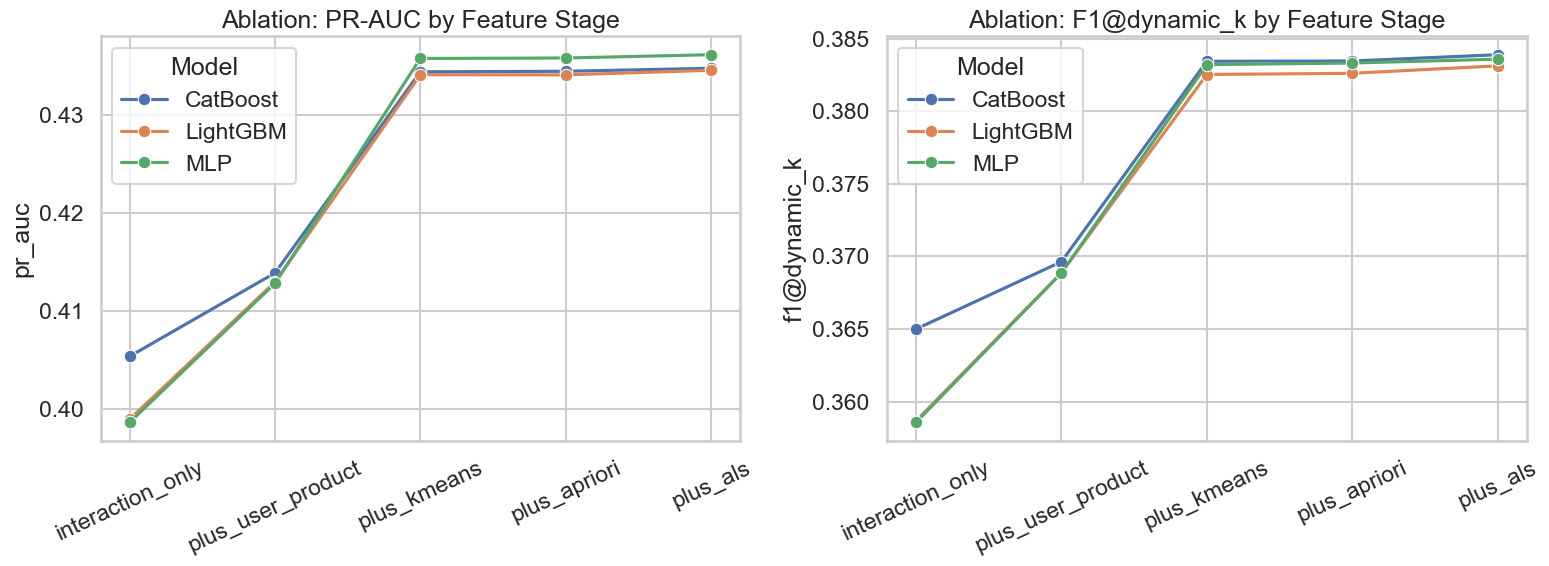

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)
plot_df = ablation_summary[ablation_summary['model'].isin(PLOT_MODELS)].copy()

sns.lineplot(data=plot_df, x='stage', y='pr_auc', hue='model', marker='o', ax=axes[0])
axes[0].set_title('Ablation: PR-AUC by Feature Stage')
axes[0].tick_params(axis='x', rotation=25)
axes[0].set_xlabel('')

sns.lineplot(data=plot_df, x='stage', y='f1@dynamic_k', hue='model', marker='o', ax=axes[1])
axes[1].set_title('Ablation: F1@dynamic_k by Feature Stage')
axes[1].tick_params(axis='x', rotation=25)
axes[1].set_xlabel('')

for ax in axes:
    ax.legend(title='Model')

plt.tight_layout()
plt.show()


## 2. Model Performance by User Segment

This section uses the final two feature settings:

- `no_als` = base features through Apriori
- `with_als` = base features plus ALS

The same out-of-fold predictions are then summarized by `user_cluster` to answer:

- which segment is easiest or hardest to predict
- which segment benefits more from ALS
- which segment benefits more from dynamic-k compared with fixed `k=11`


In [7]:
FINAL_FEATURE_SETS = {
    'no_als': ABLATION_STAGES[-2][1],
    'with_als': ABLATION_STAGES[-1][1],
}

segment_rows = []
for model_name in ANALYSIS_MODELS:
    for feature_label, feature_cols in FINAL_FEATURE_SETS.items():
        oof_df = collect_oof_predictions(model_name, feature_label, feature_cols)
        seg_base = oof_df.groupby('user_cluster').apply(
            lambda g: pd.Series(eval_row_level(g['label'].to_numpy(), g['prob'].to_numpy()))
        ).reset_index().rename(columns={'user_cluster': 'segment'})
        seg_base['users'] = oof_df.groupby('user_cluster')['user_id'].nunique().values
        seg_base['feature_set'] = feature_label
        seg_base['model'] = model_name

        fixed_metrics = collect_segment_strategy_metrics(oof_df, 'fixed_11').rename(columns={
            'precision@fixed_11': 'precision@11',
            'recall@fixed_11': 'recall@11',
            'f1@fixed_11': 'f1@11',
            'hit@fixed_11': 'hit@11',
            'avg_k@fixed_11': 'avg_k@11',
        }).drop(columns=['auc', 'pr_auc', 'logloss', 'users', 'rows'])

        dynamic_metrics = collect_segment_strategy_metrics(oof_df, 'rounded_avg_basket').rename(columns={
            'precision@rounded_avg_basket': 'precision@dynamic_k',
            'recall@rounded_avg_basket': 'recall@dynamic_k',
            'f1@rounded_avg_basket': 'f1@dynamic_k',
            'hit@rounded_avg_basket': 'hit@dynamic_k',
            'avg_k@rounded_avg_basket': 'avg_k@dynamic_k',
        }).drop(columns=['auc', 'pr_auc', 'logloss', 'users', 'rows', 'strategy'])

        merged = seg_base.merge(fixed_metrics[['segment', 'f1@11', 'hit@11']], on='segment').merge(
            dynamic_metrics[['segment', 'f1@dynamic_k', 'hit@dynamic_k', 'avg_k@dynamic_k']], on='segment'
        )
        merged['dynamic_gain_vs_f11'] = merged['f1@dynamic_k'] - merged['f1@11']
        segment_rows.append(merged)

segment_summary = pd.concat(segment_rows, ignore_index=True)
segment_summary = segment_summary.sort_values(['model', 'feature_set', 'segment']).reset_index(drop=True)
segment_summary.head(20)


no_als | LogisticRegression_SAGA | fold 1 done
no_als | LogisticRegression_SAGA | fold 2 done
no_als | LogisticRegression_SAGA | fold 3 done
with_als | LogisticRegression_SAGA | fold 1 done
with_als | LogisticRegression_SAGA | fold 2 done
with_als | LogisticRegression_SAGA | fold 3 done
no_als | LightGBM | fold 1 done
no_als | LightGBM | fold 2 done
no_als | LightGBM | fold 3 done
with_als | LightGBM | fold 1 done
with_als | LightGBM | fold 2 done
with_als | LightGBM | fold 3 done
no_als | MLP | fold 1 done
no_als | MLP | fold 2 done
no_als | MLP | fold 3 done
with_als | MLP | fold 1 done
with_als | MLP | fold 2 done
with_als | MLP | fold 3 done
no_als | CatBoost | fold 1 done
no_als | CatBoost | fold 2 done
no_als | CatBoost | fold 3 done
with_als | CatBoost | fold 1 done
with_als | CatBoost | fold 2 done
with_als | CatBoost | fold 3 done


,segment,auc,pr_auc,logloss,users,feature_set,model,f1@11,hit@11,f1@dynamic_k,hit@dynamic_k,avg_k@dynamic_k,dynamic_gain_vs_f11
0,0,0.869790,0.438194,0.382805,33064,no_als,CatBoost,0.377541,0.930135,0.397579,0.909206,11.042221,0.020038
1,1,0.850703,0.555675,0.613611,24006,no_als,CatBoost,0.348462,0.846705,0.446567,0.747230,3.603432,0.098105
2,2,0.820486,0.423539,0.561872,43435,no_als,CatBoost,0.362773,0.908000,0.375458,0.900150,12.801335,0.012685
3,3,0.794039,0.390303,0.626682,30704,no_als,CatBoost,0.313688,0.837643,0.330207,0.804749,9.675938,0.016518
4,0,0.870396,0.438234,0.382341,33064,with_als,CatBoost,0.377760,0.930317,0.397675,0.909993,11.042221,0.019915
5,1,0.851198,0.555905,0.612389,24006,with_als,CatBoost,0.348578,0.846455,0.447281,0.748063,3.603432,0.098703
6,2,0.821459,0.423907,0.560957,43435,with_als,CatBoost,0.363109,0.907632,0.375759,0.900035,12.801335,0.012650
7,3,0.795419,0.391201,0.625258,30704,with_als,CatBoost,0.314538,0.838620,0.330964,0.804846,9.675938,0.016426
8,0,0.868778,0.437149,0.190304,33064,no_als,LightGBM,0.376380,0.929682,0.396588,0.909569,11.042221,0.020208
9,1,0.850008,0.557922,0.308152,24006,no_als,LightGBM,0.348280,0.846705,0.445576,0.745647,3.603432,0.097296


In [8]:
segment_als_delta = (
    segment_summary
    .pivot_table(index=['model', 'segment'], columns='feature_set', values=['auc', 'pr_auc', 'f1@11', 'f1@dynamic_k'])
)
segment_als_delta.columns = [f'{metric}_{feature_set}' for metric, feature_set in segment_als_delta.columns]
segment_als_delta = segment_als_delta.reset_index()
segment_als_delta['delta_auc'] = segment_als_delta['auc_with_als'] - segment_als_delta['auc_no_als']
segment_als_delta['delta_pr_auc'] = segment_als_delta['pr_auc_with_als'] - segment_als_delta['pr_auc_no_als']
segment_als_delta['delta_f1@11'] = segment_als_delta['f1@11_with_als'] - segment_als_delta['f1@11_no_als']
segment_als_delta['delta_f1@dynamic_k'] = segment_als_delta['f1@dynamic_k_with_als'] - segment_als_delta['f1@dynamic_k_no_als']
segment_als_delta


,model,segment,auc_no_als,auc_with_als,f1@11_no_als,f1@11_with_als,f1@dynamic_k_no_als,f1@dynamic_k_with_als,pr_auc_no_als,pr_auc_with_als,delta_auc,delta_pr_auc,delta_f1@11,delta_f1@dynamic_k
0,CatBoost,0,0.869790,0.870396,0.377541,0.377760,0.397579,0.397675,0.438194,0.438234,0.000606,0.000040,0.000220,0.000096
1,CatBoost,1,0.850703,0.851198,0.348462,0.348578,0.446567,0.447281,0.555675,0.555905,0.000495,0.000230,0.000116,0.000714
2,CatBoost,2,0.820486,0.821459,0.362773,0.363109,0.375458,0.375759,0.423539,0.423907,0.000973,0.000368,0.000337,0.000301
3,CatBoost,3,0.794039,0.795419,0.313688,0.314538,0.330207,0.330964,0.390303,0.391201,0.001380,0.000898,0.000849,0.000757
4,LightGBM,0,0.868778,0.869403,0.376380,0.376675,0.396588,0.396846,0.437149,0.437405,0.000625,0.000256,0.000296,0.000258
5,LightGBM,1,0.850008,0.850478,0.348280,0.348406,0.445576,0.445832,0.557922,0.558043,0.000471,0.000121,0.000126,0.000256
6,LightGBM,2,0.819537,0.820497,0.362164,0.362646,0.374586,0.375254,0.422996,0.423538,0.000961,0.000542,0.000482,0.000669
7,LightGBM,3,0.793208,0.794497,0.313097,0.314087,0.329660,0.330427,0.390761,0.391822,0.001290,0.001061,0.000990,0.000767
8,LogisticRegression_SAGA,0,0.856940,0.857291,0.359012,0.358820,0.376499,0.376074,0.403568,0.403631,0.000351,0.000063,-0.000192,-0.000425
9,LogisticRegression_SAGA,1,0.833700,0.834502,0.346149,0.346255,0.431455,0.432057,0.524256,0.525136,0.000802,0.000880,0.000105,0.000602


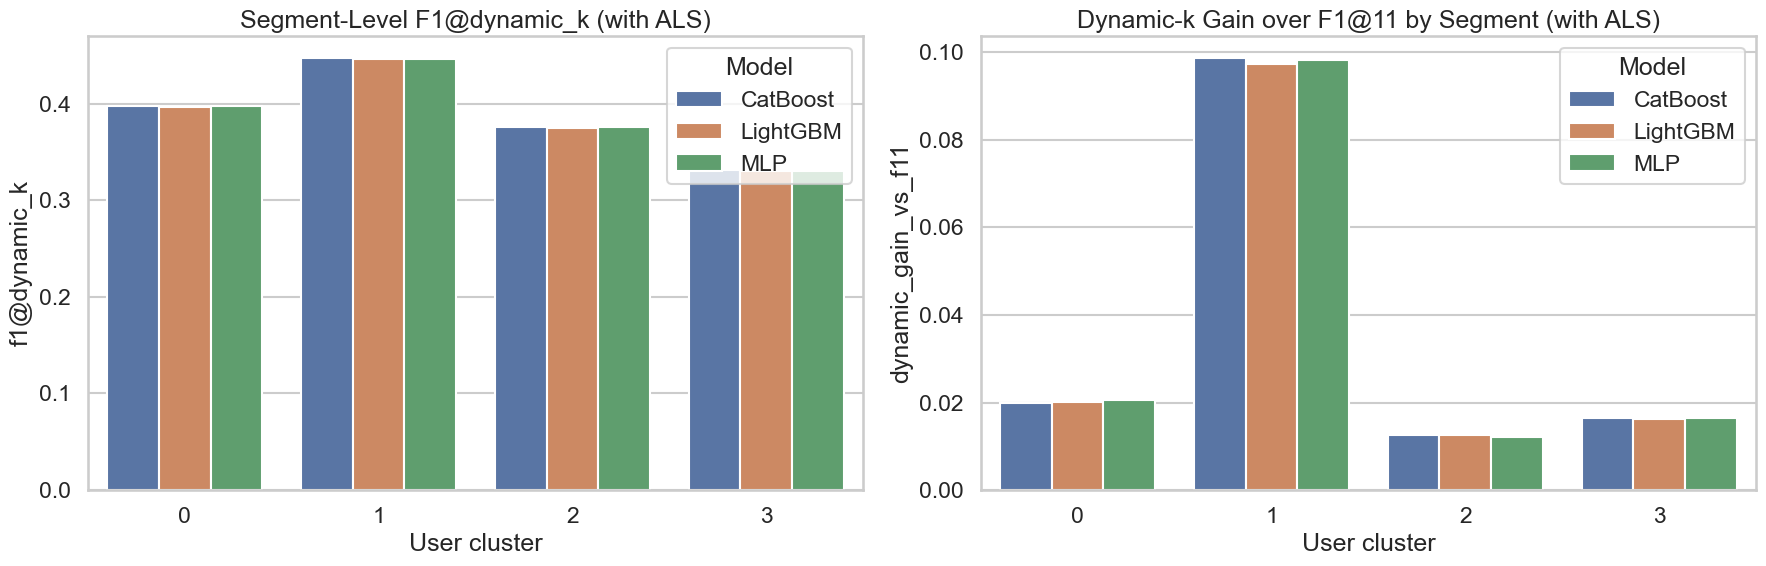

In [9]:
plot_seg = segment_summary[(segment_summary['feature_set'] == 'with_als') & (segment_summary['model'].isin(PLOT_MODELS))].copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.barplot(data=plot_seg, x='segment', y='f1@dynamic_k', hue='model', ax=axes[0])
axes[0].set_title('Segment-Level F1@dynamic_k (with ALS)')
axes[0].set_xlabel('User cluster')

sns.barplot(data=plot_seg, x='segment', y='dynamic_gain_vs_f11', hue='model', ax=axes[1])
axes[1].set_title('Dynamic-k Gain over F1@11 by Segment (with ALS)')
axes[1].set_xlabel('User cluster')

for ax in axes:
    ax.legend(title='Model')

plt.tight_layout()
plt.show()


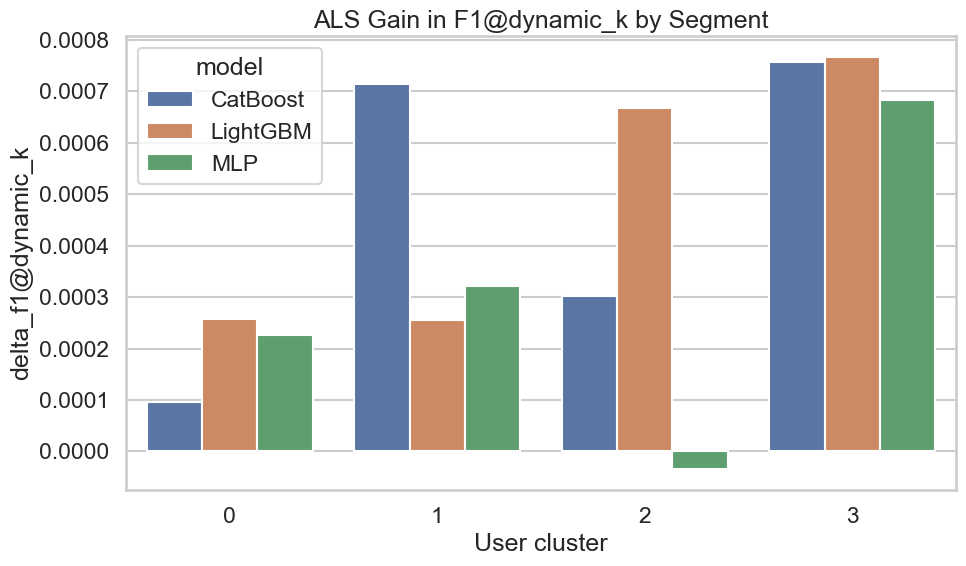

In [10]:
plot_als_seg = segment_als_delta[segment_als_delta['model'].isin(PLOT_MODELS)].copy()
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=plot_als_seg, x='segment', y='delta_f1@dynamic_k', hue='model', ax=ax)
ax.set_title('ALS Gain in F1@dynamic_k by Segment')
ax.set_xlabel('User cluster')
plt.tight_layout()
plt.show()


## 3. Top-K Strategy Comparison

In the current pipeline, `dynamic-k` is based on the rounded historical average basket size. This section makes that choice explicit and compares it against:

- fixed `k = 11`
- rounded average basket size
- ceiling average basket size

The comparison uses the final `with_als` feature set by default.


In [11]:
topk_rows = []
for model_name in ANALYSIS_MODELS:
    oof_df = collect_oof_predictions(model_name, 'with_als', FINAL_FEATURE_SETS['with_als'])
    row_level = eval_row_level(oof_df['label'].to_numpy(), oof_df['prob'].to_numpy())
    for strategy in TOPK_STRATEGIES:
        strategy_metrics = eval_order_with_k_map(
            oof_df[['user_id', 'product_id', 'label', 'u_avg_basket_size', 'prob']].copy(),
            make_k_map(oof_df, strategy),
            prefix='strategy',
        )
        row = {
            'model': model_name,
            'feature_set': 'with_als',
            'strategy': strategy,
            **row_level,
            'precision': strategy_metrics['precision@strategy'],
            'recall': strategy_metrics['recall@strategy'],
            'f1': strategy_metrics['f1@strategy'],
            'hit': strategy_metrics['hit@strategy'],
            'avg_k': strategy_metrics['avg_k@strategy'],
        }
        topk_rows.append(row)

topk_strategy_summary = pd.DataFrame(topk_rows).sort_values(['model', 'strategy']).reset_index(drop=True)
topk_strategy_summary


,model,feature_set,strategy,auc,pr_auc,logloss,precision,recall,f1,hit,avg_k
0,CatBoost,with_als,ceil_avg_basket,0.846847,0.434816,0.485225,0.331282,0.548544,0.382510,0.859095,10.378495
1,CatBoost,with_als,fixed_11,0.846847,0.434816,0.485225,0.305738,0.586792,0.352777,0.886006,11.000000
2,CatBoost,with_als,rounded_avg_basket,0.846847,0.434816,0.485225,0.340982,0.532018,0.383885,0.852464,9.943830
3,LightGBM,with_als,ceil_avg_basket,0.845921,0.434608,0.239565,0.330797,0.547730,0.381923,0.858935,10.378495
4,LightGBM,with_als,fixed_11,0.845921,0.434608,0.239565,0.305232,0.586129,0.352213,0.886075,11.000000
5,LightGBM,with_als,rounded_avg_basket,0.845921,0.434608,0.239565,0.340323,0.530999,0.383118,0.852175,9.943830
6,LogisticRegression_SAGA,with_als,ceil_avg_basket,0.834442,0.406399,0.504515,0.319669,0.530716,0.369461,0.853661,10.378495
7,LogisticRegression_SAGA,with_als,fixed_11,0.834442,0.406399,0.504515,0.296254,0.572355,0.342667,0.882843,11.000000
8,LogisticRegression_SAGA,with_als,rounded_avg_basket,0.834442,0.406399,0.504515,0.328334,0.513726,0.370027,0.846100,9.943830
9,MLP,with_als,ceil_avg_basket,0.846136,0.436201,0.239393,0.331127,0.547957,0.382278,0.858470,10.378495


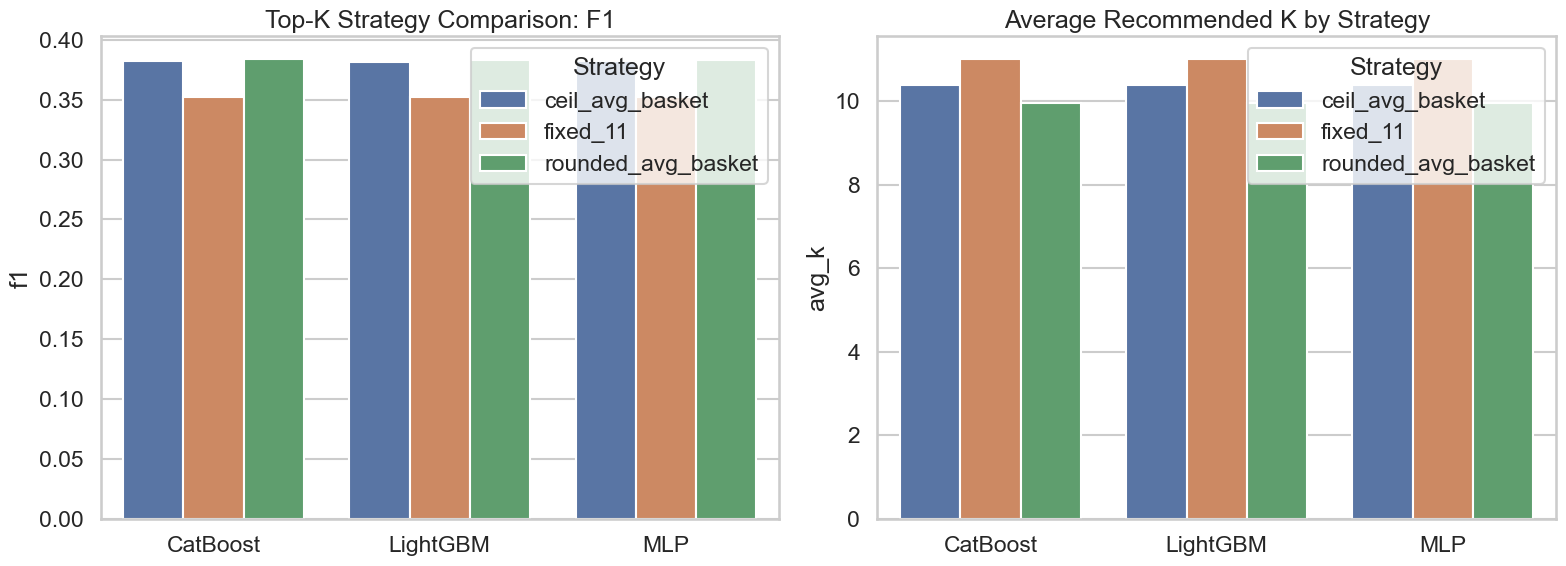

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_topk = topk_strategy_summary[topk_strategy_summary['model'].isin(PLOT_MODELS)].copy()

sns.barplot(data=plot_topk, x='model', y='f1', hue='strategy', ax=axes[0])
axes[0].set_title('Top-K Strategy Comparison: F1')
axes[0].set_xlabel('')
axes[0].legend(title='Strategy')

sns.barplot(data=plot_topk, x='model', y='avg_k', hue='strategy', ax=axes[1])
axes[1].set_title('Average Recommended K by Strategy')
axes[1].set_xlabel('')
axes[1].legend(title='Strategy')

plt.tight_layout()
plt.show()


In [13]:
segment_topk_rows = []
for model_name in ANALYSIS_MODELS:
    oof_df = collect_oof_predictions(model_name, 'with_als', FINAL_FEATURE_SETS['with_als'])
    for strategy in TOPK_STRATEGIES:
        seg_df = collect_segment_strategy_metrics(oof_df, strategy).rename(columns={
            f'precision@{strategy}': 'precision',
            f'recall@{strategy}': 'recall',
            f'f1@{strategy}': 'f1',
            f'hit@{strategy}': 'hit',
            f'avg_k@{strategy}': 'avg_k',
        })
        seg_df['model'] = model_name
        segment_topk_rows.append(seg_df[['model', 'segment', 'strategy', 'users', 'rows', 'auc', 'pr_auc', 'logloss', 'precision', 'recall', 'f1', 'hit', 'avg_k']])

segment_topk_summary = pd.concat(segment_topk_rows, ignore_index=True)
segment_topk_summary.head(20)


,model,segment,strategy,users,rows,auc,pr_auc,logloss,precision,recall,f1,hit,avg_k
0,LogisticRegression_SAGA,0,fixed_11,33064,4071728,0.857291,0.403631,0.402644,0.351381,0.472457,0.358820,0.925387,11.000000
1,LogisticRegression_SAGA,1,fixed_11,24006,360433,0.834502,0.525136,0.645160,0.241144,0.802746,0.346255,0.844830,11.000000
2,LogisticRegression_SAGA,2,fixed_11,43435,3001516,0.810119,0.399404,0.577634,0.326128,0.494071,0.352291,0.905031,11.000000
3,LogisticRegression_SAGA,3,fixed_11,30704,1040984,0.784433,0.375116,0.643457,0.237718,0.610542,0.308851,0.835363,11.000000
4,LogisticRegression_SAGA,0,rounded_avg_basket,33064,4071728,0.857291,0.403631,0.402644,0.365159,0.444282,0.376074,0.902522,11.042221
5,LogisticRegression_SAGA,1,rounded_avg_basket,24006,360433,0.834502,0.525136,0.645160,0.395987,0.553740,0.432057,0.736191,3.603432
6,LogisticRegression_SAGA,2,rounded_avg_basket,43435,3001516,0.810119,0.399404,0.577634,0.313945,0.517855,0.364223,0.895959,12.801335
7,LogisticRegression_SAGA,3,rounded_avg_basket,30704,1040984,0.784433,0.375116,0.643457,0.256140,0.551384,0.323228,0.800743,9.675938
8,LogisticRegression_SAGA,0,ceil_avg_basket,33064,4071728,0.857291,0.403631,0.402644,0.358249,0.458706,0.377643,0.907906,11.527916
9,LogisticRegression_SAGA,1,ceil_avg_basket,24006,360433,0.834502,0.525136,0.645160,0.372459,0.588334,0.428338,0.755228,4.021953


In [14]:
# Save the new supplementary outputs so they can be reused in the report or poster.
ablation_path = ARTIFACTS_DIR / 'supplementary_ablation_summary.csv'
segment_path = ARTIFACTS_DIR / 'supplementary_segment_summary.csv'
segment_als_path = ARTIFACTS_DIR / 'supplementary_segment_als_delta.csv'
topk_path = ARTIFACTS_DIR / 'supplementary_topk_strategy_summary.csv'
segment_topk_path = ARTIFACTS_DIR / 'supplementary_segment_topk_summary.csv'

ablation_summary.to_csv(ablation_path, index=False)
segment_summary.to_csv(segment_path, index=False)
segment_als_delta.to_csv(segment_als_path, index=False)
topk_strategy_summary.to_csv(topk_path, index=False)
segment_topk_summary.to_csv(segment_topk_path, index=False)

print('Saved:')
for path in [ablation_path, segment_path, segment_als_path, topk_path, segment_topk_path]:
    print('-', path)


Saved:
- /Users/bettinabopeng/Documents/GitHub/5971/artifacts/supplementary_ablation_summary.csv
- /Users/bettinabopeng/Documents/GitHub/5971/artifacts/supplementary_segment_summary.csv
- /Users/bettinabopeng/Documents/GitHub/5971/artifacts/supplementary_segment_als_delta.csv
- /Users/bettinabopeng/Documents/GitHub/5971/artifacts/supplementary_topk_strategy_summary.csv
- /Users/bettinabopeng/Documents/GitHub/5971/artifacts/supplementary_segment_topk_summary.csv
